In [38]:
import pyart
import matplotlib.pyplot as plt
import numpy as np
import math
import warnings
import time
import pylab as pl
from IPython import display
import glob
import pandas as pd
import datetime as dt
import zipfile
import xarray as xr
from mpl_toolkits.basemap import Basemap 
import tqdm
warnings.simplefilter("ignore")
%matplotlib inline

In [28]:
daily_obs = pd.read_pickle("/g/data/eg3/ab4502/ExtremeWind/obs/aws/convective_wind_gust_aus_2005_2018.pkl")
aws_info = pd.read_fwf("/home/548/ab4502/working/observations/vic_onemin_gust_sites.txt", header=None, 
                  names=["site","name","lat","lon","start1","start2","end1","end2","years","%","obs","AWS"]).query("(lat<-36) & (lon >143) & (lon <146.5)")
one_min=pd.read_csv("/g/data/eg3/ab4502/HD01D_Data_999999999972395.txt",names=["hd",'no','t1','y2','t3','t4','t5','year','month','day','hour','minute','gust','#'],header=0)
one_min["dt"]=pd.to_datetime(one_min[["year","month","day","hour","minute"]])
one_min["gust"]=pd.to_numeric(one_min["gust"], errors="coerce")
one_min = one_min.set_index("dt")

In [29]:
daily_obs[daily_obs["stn_name"]=="Melbourne"].dropna(subset=["wind_gust"]).sort_values("wind_gust",ascending=False).iloc[0:1][["gust_time_utc","wind_gust","lightning"]]

,gust_time_utc,wind_gust,lightning
489797,2015-02-28 09:25:00,34.0,65.0


In [30]:
def load_radar(rid, time, radar_t_delta=0):

    #time: Time of interest (in this context, the time of maximum BARPAC gust). datetime object
    #rid: Radar ID (https://www.openradar.io/operational-network). two-digit string
    #radar_t_delta: Add some interval (in minutes) to look at a time relative to the time of maximum model gust. integer
    
    time = time + dt.timedelta(minutes=radar_t_delta)
    
    isfile = len(glob.glob("/g/data/eg3/ab4502/radar/"+rid+"_"+time.strftime("%Y%m%d")+"*")) > 0
    
    if not isfile:
        print("INFO: UNPACKING RADAR FILE FOR ID "+rid+" AND TIME "+time.strftime("%Y%m%d"))
        path_to_zip_file = "/g/data/rq0/level_1/odim_pvol/"+rid+"/"+str(time.year)+"/vol/"+rid+"_"+time.strftime("%Y%m%d")+".pvol.zip"
        directory_to_extract_to = "/g/data/eg3/ab4502/radar/"
        with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
            zip_ref.extractall(directory_to_extract_to)
        
    else:
        print("INFO: LOADING RADAR FILE FOR ID "+rid+" AND TIME "+time.strftime("%Y%m%d"))
        
    files = glob.glob("/g/data/eg3/ab4502/radar/"+rid+"_"+time.strftime("%Y%m%d")+"*")
    f_times = [fname.split("/")[-1].split("_")[2].split(".")[0] for fname in files]
    radar_file=pyart.aux_io.read_odim_h5(\
                              files[np.argmin(np.array([abs(time-dt.datetime(time.year,time.month,time.day,int(f[0:2]),int(f[2:4]),int(f[4:6]))) for f in f_times]))],\
                              file_field_names=True)
    return radar_file

radar=load_radar("02",dt.datetime(2015,2,28))

INFO: LOADING RADAR FILE FOR ID 02 AND TIME 20150228


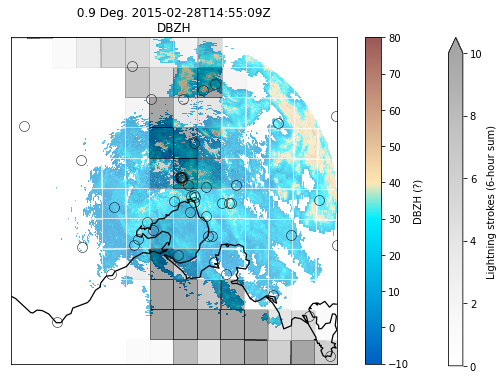

100%|██████████| 80/80 [02:16<00:00,  1.71s/it]


In [161]:
step=1; start_ind=70; end_ind=150
files=np.sort(glob.glob("/g/data/eg3/ab4502/radar/02_20150228*"))
lightning=xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/ad_data/lightning/lightning_Australasia0.250000degree_6.00000hr_2015.nc",
            decode_times=False)
lightning_x,lightning_y=np.meshgrid(lightning.lon.values, lightning.lat.values)
m = Basemap(llcrnrlon=142, llcrnrlat=-42, urcrnrlon=148, urcrnrlat=-34,projection="cyl",resolution="h")
for i in tqdm.tqdm(np.arange(start_ind,end_ind,step)):
    fig=plt.figure(figsize=[10,6])
    ax=plt.gca()
    radar_prev = pyart.aux_io.read_odim_h5(files[i-1], file_field_names=True)
    radar = pyart.aux_io.read_odim_h5(files[i], file_field_names=True)    
    disp=pyart.graph.RadarMapDisplayBasemap(radar)
    c=disp.plot_ppi_map("DBZH",1,cmap=pyart.graph.cm.BlueBrown10, resolution="i",vmax=80, ax=ax)
    disp.basemap.plot(aws_info["lon"].values,aws_info["lat"].values, marker="o", ms=10, mew=0.5,
                      color="k", latlon=True, mfc="none", linestyle="none", ax=ax)
    current_time = pyart.util.datetime_from_radar(radar).strftime("%Y-%m-%d %H:%M")
    prev_time = pyart.util.datetime_from_radar(radar_prev).strftime("%Y-%m-%d %H:%M")
    scw_stns = one_min.loc[slice(prev_time,current_time)].groupby("no").max().reset_index().query("gust>25")
    x,y=disp.basemap(aws_info[np.in1d(aws_info["site"],scw_stns["no"])]["lon"].values,
                     aws_info[np.in1d(aws_info["site"],scw_stns["no"])]["lat"].values)
    [plt.text(x[i],y[i],scw_stns["gust"].iloc[i], fontweight="bold", size=18, color="tab:red",
              va="center", ha="center") for i in np.arange(len(x))]
    
    lightning_x,lightning_y=np.meshgrid(lightning.lon.values, lightning.lat.values)
    lightning_x, lightning_y = disp.basemap(lightning_x, lightning_y)
    lcont = disp.basemap.pcolormesh(lightning_x,lightning_y,
                lightning.interp({"time":(dt.datetime.strptime(current_time,"%Y-%m-%d %H:%M") - dt.datetime(2015,1,1)).
                                  total_seconds() / 3600}, method="nearest")["Lightning_observed"].values
                            ,vmax=10,cmap=plt.get_cmap("Greys"),ax=ax,alpha=0.35,edgecolors="face")
    cb=plt.colorbar(lcont,cax=plt.axes([0.9,0.12,0.02,0.76]), extend="max")
    cb.set_label("Lightning strokes (6-hour sum)")
    
    display.clear_output(wait=True)
    display.display(pl.gcf())
    
    plt.savefig("/g/data/eg3/ab4502/figs/melb_radar_example/"+f'{i:03d}'+".jpg", bbox_inches="tight")
    
    plt.close()

!convert -delay 20 -loop 0 /g/data/eg3/ab4502/figs/melb_radar_example/*.jpg /g/data/eg3/ab4502/figs/melb_radar_example/myimage.gif

In [93]:
group=one_min.groupby("no")
for n, g in group:
    try:
        print(n, g["gust"].max())
    except:
        print(n)

79101  21.6
80091  14.9
80128  17.5
81049  15.4
81123  19.0
81124  15.1
81125  19.5
82138  11.3
83024  20.6
85096  17.5
85099  20.0
85280  15.9
85291  17.0
85301  13.2
85313  15.1
86038  26.2
86068  25.2
86077  23.1
86104  18.8
86220  35.3
86266  12.5
86282  34.0
86338  13.4
86344  26.2
86361  25.3
86371  25.7
86373  20.4
86376  36.5
86383  22.6
86395  31.9
86396  25.2
86397  32.9
86398  33.4
87031  27.8
87113  20.6
87166  24.7
87168  20.6
87184  17.0
88051  16.1
88109  20.6
88162  17.0
88164  20.0
89002  20.6
90015  13.9
90035  19.4
90180


In [91]:
pd.to_numeric(one_min.query("no==86282").set_index("dt")["gust"]).plot()

KeyError: "None of ['dt'] are in the columns"

In [93]:
!convert -delay 20 -loop 0 /g/data/eg3/ab4502/figs/melb_radar_example/*.jpg /g/data/eg3/ab4502/figs/melb_radar_example/myimage.gif

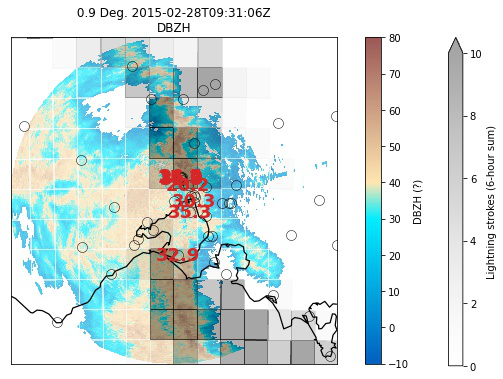

In [171]:
from PIL import Image
Image.open("/g/data/eg3/ab4502/figs/melb_radar_example/095.jpg")

In [159]:
grid = pyart.map.map_to_grid(radar, grid_shape=(41, 301, 301), grid_limits=((0, 20e3), (-150e3, 150e3), (-150e3, 150e3)),)


In [ ]:
grid = pyart.map.map_to_grid